In [ ]:
# Full ML Cycle Habit Tracker (run this at the start of each project)

project_name = "SET_THIS_PROJECT_NAME"

cycle_steps = [
    "1_problem_definition",
    "2_data_collection_and_scope",
    "3_data_transformation_and_processing",
    "4_baseline_model_or_system",
    "5_evaluation_metrics_and_results",
    "6_error_analysis",
    "7_improvement_iteration",
    "8_deployment_or_handoff_notes",
]

status = {step: "TODO" for step in cycle_steps}
evidence = {step: "" for step in cycle_steps}

def mark_done(step, note=""):
    if step not in status:
        raise ValueError(f"Unknown step: {step}")
    status[step] = "DONE"
    evidence[step] = note

def show_progress():
    done_count = sum(1 for v in status.values() if v == "DONE")
    total = len(status)
    print(f"\nProject: {project_name}")
    print(f"Progress: {done_count}/{total} steps complete")
    for step in cycle_steps:
        note = f" | note: {evidence[step]}" if evidence[step] else ""
        print(f"- {step}: {status[step]}{note}")

# Example usage:
# mark_done("3_data_transformation_and_processing", "Handled missing values and encoded categories")
# mark_done("5_evaluation_metrics_and_results", "F1=0.81, recall=0.86")
show_progress()

# Full Process Lens For This Project

Use this section every time you start a project so you practice the same end-to-end workflow, not just isolated coding tasks.

## 1) Data Transformation and Processing (What and Why)

Raw data is rarely model-ready. Your first job is to transform data into a reliable, learnable format.

What to do in every project:
- Identify data types and expected schema.
- Handle missing values, duplicates, and inconsistent formats.
- Convert features into model-usable representations (encoding, scaling, tokenization, chunking, etc.).
- Keep transformations reproducible so train and inference use the same logic.
- Document assumptions and risks introduced by preprocessing choices.

Why this matters:
- Better preprocessing usually improves results more than switching algorithms.
- Poor preprocessing creates hidden errors that look like model failure.

## 2) Evaluating and Improving Models (What and Why)

Evaluation is not the last step. It is the loop that drives improvement.

What to do in every project:
- Start with a baseline and compare against it.
- Choose metrics tied to the real goal (not just convenience metrics).
- Inspect errors by slice (segments, classes, edge cases).
- Tune thresholds, features, prompts, retrieval settings, or hyperparameters based on evidence.
- Re-evaluate after each change and keep track of what improved and what regressed.

Why this matters:
- A model can appear good overall but fail on important cases.
- Iterative evaluation is how projects become production-ready, not just demo-ready.

## 3) Project Reflection Checklist

Before marking this project complete, confirm:
- I can explain how data was transformed and why.
- I can explain which metrics I chose and why.
- I can show at least one improvement cycle from evaluation findings.
- I can describe current limitations and next improvements.

# Week 0 — ML 101: What Is Machine Learning?
> **Phase 0 | Beginner Foundation** — No prior knowledge required.

---

## Beginner Start Here

Welcome! This notebook is your **very first step**. You will not write any complex code yet. The goal of Week 0 is to understand the big picture: what is AI, what is machine learning, and how does the whole field fit together?

### What You Will Learn
- The difference between AI, Machine Learning, and Data Science
- The 3 main types of machine learning (with real-world examples)
- The 6-step ML workflow every project follows
- Why Python is the language of choice for ML/AI
- How to run code in a Jupyter notebook

### How to Use This Notebook
1. Read each markdown cell (the text cells like this one).
2. Run each code cell by clicking it and pressing **Shift + Enter**.
3. Don't skip the reflection questions — writing your answers is how you actually learn.
4. If something is confusing, re-read the explanation above the code. It's all explained.

### Key Terms (Glossary for This Week)
| Term | Plain English |
|------|---------------|
| **Artificial Intelligence (AI)** | The broad field of building machines that can do tasks that normally require human intelligence |
| **Machine Learning (ML)** | A *subset* of AI where machines learn patterns from data instead of being given explicit rules |
| **Data Science** | The practice of extracting insights and value from data — overlaps heavily with ML |
| **Model** | An algorithm that has been trained on data and can now make predictions |
| **Training** | Feeding a model data so it can learn patterns |
| **Inference** | Using a trained model to make predictions on new data |
| **Feature** | An input variable (a column in your data) used to make predictions |
| **Label / Target** | The thing you're trying to predict (the answer) |
| **Dataset** | A collection of data — usually rows and columns, like a spreadsheet |

---

## Section 1: AI vs Machine Learning vs Data Science

People use these terms interchangeably, but they mean different things. Here is the relationship:

```
┌─────────────────────────────────┐
│         Artificial Intelligence │
│  ┌──────────────────────────┐   │
│  │      Machine Learning    │   │
│  │  ┌────────────────────┐  │   │
│  │  │   Deep Learning    │  │   │
│  │  └────────────────────┘  │   │
│  └──────────────────────────┘   │
└─────────────────────────────────┘
```

- **AI** is the outermost box — any technique that makes a computer act intelligently. This includes expert systems, rule-based systems, robotics, speech recognition, and much more.
- **Machine Learning** is inside AI — it's specifically about systems that *learn from data*. Instead of a programmer writing `if price > 500 then label = expensive`, the ML model figures out that rule on its own by looking at thousands of examples.
- **Deep Learning** is inside ML — it uses extremely large, layered neural networks (like the human brain). This is behind ChatGPT, image recognition, and voice assistants.
- **Data Science** sits to the side — it focuses on the full cycle of collecting, cleaning, analyzing, visualizing, and modeling data. You'll use ML as one of your tools inside data science.

**The key insight:** ML is not magic. It is a system that finds patterns in past data and uses them to predict future data. That's it.

In [1]:
# ── First run check ──────────────────────────────────────────────────────────
# Let's confirm Python is working and print a friendly welcome.
# How to run: click this cell, then press Shift + Enter

print("Python is working! You're on your way.")
print()
print("The AI field breakdown:")
print("  AI  ⊃  Machine Learning  ⊃  Deep Learning")
print()

# Python can do simple math too:
years_to_master_ml = 2
hours_per_week = 10
total_hours = years_to_master_ml * 52 * hours_per_week
print(f"If you study {hours_per_week} hours/week for {years_to_master_ml} years = {total_hours} total hours")
print("That's enough to become job-ready. Let's go.")

Python is working! You're on your way.

The AI field breakdown:
  AI  ⊃  Machine Learning  ⊃  Deep Learning

If you study 10 hours/week for 2 years = 1040 total hours
That's enough to become job-ready. Let's go.


---

## Section 2: The 3 Types of Machine Learning

Every ML problem fits into one of three categories. Knowing which type you're dealing with tells you which algorithms to use.

### Type 1: Supervised Learning
**What it is:** You give the model labeled examples (input + correct answer). The model learns to map inputs to outputs.

**Real-world examples:**
- Email spam filter → input: email text, label: spam/not spam
- House price prediction → input: sq ft, bedrooms, location, label: price
- Medical diagnosis → input: symptoms/tests, label: disease/no disease

**Two subtypes:**
- **Classification** — the output is a category (spam/not spam, cat/dog, disease A/B/none)
- **Regression** — the output is a number (price, temperature, sales)

---

### Type 2: Unsupervised Learning
**What it is:** You give the model data with NO labels. The model finds hidden structure or patterns on its own.

**Real-world examples:**
- Customer segmentation → find groups of similar customers (without telling the model what groups to find)
- Anomaly detection → find unusual transactions in millions of credit card records
- Topic modeling → find themes across 10,000 news articles

---

### Type 3: Reinforcement Learning
**What it is:** An agent learns by taking actions in an environment and receiving rewards or penalties. It learns what actions maximize reward over time.

**Real-world examples:**
- AlphaGo beating the world Go champion
- Self-driving car learning to stay in lane
- Recommendation systems optimizing for clicks/watch time

---

> **For 2026 job-readiness:** Focus first on Supervised Learning (weeks 1-8). It covers 80% of business ML use cases. Unsupervised and RL come later.

In [1]:
# ── Section 2 Exercise: Classify these problems ───────────────────────────────
# For each problem below, decide: Supervised or Unsupervised? Classification or Regression?
# Edit 'your_answer' for each one. Then run the cell to check.

problems = [
    {
        "problem": "Predict whether a loan applicant will default (yes/no)",
        "your_answer": "supervised-classification",   # <-- Fill in: 'supervised-classification', 'supervised-regression', or 'unsupervised'
        "correct": "supervised-classification",
        "why": "You have labeled data (past loans that did/did not default) → supervised. Output is yes/no → classification."
    },
    {
        "problem": "Predict next month's sales revenue ($)",
        "your_answer": "supervised-regression",
        "correct": "supervised-regression",
        "why": "You have labeled data (past sales records) → supervised. Output is a number → regression."
    },
    {
        "problem": "Group 1 million customer profiles into behavior segments",
        "your_answer": "unsupervised",
        "correct": "unsupervised",
        "why": "No labels — you don't know what the groups are beforehand → unsupervised (clustering)."
    },
    {
        "problem": "Detect fraudulent credit card transactions",
        "your_answer": "supervised-classification",
        "correct": "supervised-classification",
        "why": "You have labeled historical data (fraud / not-fraud). Output is a category → supervised classification."
    },
]

print("=" * 60)
print("ML TYPE EXERCISE RESULTS")
print("=" * 60)
score = 0
for i, p in enumerate(problems, 1):
    ans = p["your_answer"].strip().lower()
    correct = p["correct"]
    status = "✅ CORRECT" if ans == correct else f"❌ Wrong (answer: {correct})"
    not_answered = ans == ""
    if not_answered:
        status = "⬜ Not answered yet"
    else:
        if ans == correct:
            score += 1
    print(f"\nQ{i}: {p['problem']}")
    print(f"     Your answer: '{p['your_answer']}'")
    print(f"     {status}")
    print(f"     Why: {p['why']}")
print(f"\nScore: {score}/{len(problems)} (fill in your_answer above and re-run to check)")

ML TYPE EXERCISE RESULTS

Q1: Predict whether a loan applicant will default (yes/no)
     Your answer: 'supervised-classification'
     ✅ CORRECT
     Why: You have labeled data (past loans that did/did not default) → supervised. Output is yes/no → classification.

Q2: Predict next month's sales revenue ($)
     Your answer: 'supervised-regression'
     ✅ CORRECT
     Why: You have labeled data (past sales records) → supervised. Output is a number → regression.

Q3: Group 1 million customer profiles into behavior segments
     Your answer: 'unsupervised'
     ✅ CORRECT
     Why: No labels — you don't know what the groups are beforehand → unsupervised (clustering).

Q4: Detect fraudulent credit card transactions
     Your answer: 'supervised-classification'
     ✅ CORRECT
     Why: You have labeled historical data (fraud / not-fraud). Output is a category → supervised classification.

Score: 4/4 (fill in your_answer above and re-run to check)


---

## Section 3: The 6-Step ML Workflow

Every single ML project — from a simple spam filter to a billion-dollar recommendation system — follows the same 6 steps. Learning this framework is the most important thing in Week 0. Everything else is just details inside one of these steps.

```
Step 1: Define the Problem
         ↓
Step 2: Collect & Explore the Data
         ↓
Step 3: Prepare the Data (Cleaning + Feature Engineering)
         ↓
Step 4: Choose & Train a Model
         ↓
Step 5: Evaluate the Model
         ↓
Step 6: Deploy & Monitor
```

### Step 1: Define the Problem
Before touching any code, ask:
- What are we trying to predict?
- What data do we have?
- How will we measure success?
- What's the business value?

Example: "We want to predict which customers will cancel their subscription (churn) in the next 30 days, so we can send them a discount offer. Success = we correctly identify 70% of churners."

### Step 2: Collect & Explore the Data (EDA)
- Get the raw data (CSV file, database, API, web scrape)
- Explore it: how many rows? What columns? Any missing values? Any weird patterns?
- Tools: **pandas** for data, **matplotlib/seaborn** for charts

### Step 3: Prepare the Data
- Fill or drop missing values
- Encode categorical text columns as numbers (ML models only understand numbers)
- Scale numeric columns if needed
- Split data into training set and test set
- Tool: **scikit-learn** (sklearn) preprocessors

### Step 4: Choose & Train a Model
- Pick an algorithm (start simple: Logistic Regression, Decision Tree, Random Forest)
- Fit the model on training data
- Tool: **scikit-learn**

### Step 5: Evaluate the Model
- Test on data the model has never seen
- Measure accuracy, precision, recall, F1 (for classification) or MAE, RMSE (for regression)
- Compare models and pick the best

### Step 6: Deploy & Monitor
- Package the model into an API so other systems can use it
- Monitor for data drift (the real world changes over time)
- Tool: **FastAPI**, **MLflow**, **evidently**

> This roadmap teaches all 6 steps, in order, across 39 weeks.

In [3]:
# ── Section 3 Exercise: Map steps to a real project ──────────────────────────
# A junior data scientist is working on a house price prediction project.
# Below are activities they did (in random order). Match each to a step number (1-6).

activities = [
    {
        "activity": "Ran model.fit(X_train, y_train) in scikit-learn",
        "your_step": 0,   # <-- Fill in a number 1-6
        "correct_step": 4,
        "reason": "Fitting (training) a model = Step 4"
    },
    {
        "activity": "Filled in missing bedroom count with the median value",
        "your_step": 0,
        "correct_step": 3,
        "reason": "Handling missing values = Step 3 (Data Preparation)"
    },
    {
        "activity": "Created a scatter plot of house size vs price to spot a linear trend",
        "your_step": 0,
        "correct_step": 2,
        "reason": "Exploring the data with visualizations = Step 2 (EDA)"
    },
    {
        "activity": "Decided to predict house price (in $) using bedroom count, size, and zip code",
        "your_step": 0,
        "correct_step": 1,
        "reason": "Defining what to predict and what data to use = Step 1"
    },
    {
        "activity": "Calculated RMSE = $28,000 on the test set",
        "your_step": 0,
        "correct_step": 5,
        "reason": "Measuring model error on unseen test data = Step 5 (Evaluate)"
    },
    {
        "activity": "Built a FastAPI endpoint at /predict that takes house features and returns a price",
        "your_step": 0,
        "correct_step": 6,
        "reason": "Serving the model as an API = Step 6 (Deploy)"
    },
]

print("=" * 60)
print("6-STEP WORKFLOW EXERCISE")
print("=" * 60)
score = 0
for a in activities:
    correct = a["your_step"] == a["correct_step"]
    not_answered = a["your_step"] == 0
    if not_answered:
        status = "⬜ Not answered"
    elif correct:
        status = "✅ CORRECT"
        score += 1
    else:
        status = f"❌ Wrong (correct: Step {a['correct_step']})"
    print(f"\nActivity: {a['activity']}")
    print(f"  Your step: {a['your_step']} — {status}")
    print(f"  Reason: {a['reason']}")
print(f"\nScore: {score}/{len(activities)}")

6-STEP WORKFLOW EXERCISE

Activity: Ran model.fit(X_train, y_train) in scikit-learn
  Your step: 0 — ⬜ Not answered
  Reason: Fitting (training) a model = Step 4

Activity: Filled in missing bedroom count with the median value
  Your step: 0 — ⬜ Not answered
  Reason: Handling missing values = Step 3 (Data Preparation)

Activity: Created a scatter plot of house size vs price to spot a linear trend
  Your step: 0 — ⬜ Not answered
  Reason: Exploring the data with visualizations = Step 2 (EDA)

Activity: Decided to predict house price (in $) using bedroom count, size, and zip code
  Your step: 0 — ⬜ Not answered
  Reason: Defining what to predict and what data to use = Step 1

Activity: Calculated RMSE = $28,000 on the test set
  Your step: 0 — ⬜ Not answered
  Reason: Measuring model error on unseen test data = Step 5 (Evaluate)

Activity: Built a FastAPI endpoint at /predict that takes house features and returns a price
  Your step: 0 — ⬜ Not answered
  Reason: Serving the model as an 

---

## Section 4: Why Python for ML/AI?

Python became the dominant language for ML and data science for several reasons:

1. **Simple, readable syntax** — Less time fighting the language, more time thinking about the problem
2. **Massive ecosystem** — Every major ML library (NumPy, pandas, scikit-learn, PyTorch, HuggingFace) is Python-first
3. **Community** — Largest ML community in the world = more tutorials, Stack Overflow answers, and hiring
4. **Notebooks** — Jupyter notebooks (like this file) let you combine code, results, and explanation in one place — perfect for data exploration
5. **Industry standard** — Google, Meta, OpenAI, Airbnb, Netflix all use Python for ML

### What You Will Actually Code This Roadmap

| Phase | What You'll Code |
|-------|------------------|
| Phase 0 (Weeks 0-4) | Python basics, data manipulation, visualization |
| Phase 1 (Weeks 1-10) | ML pipelines, classification, regression, RAG, agents |
| Phase 2 (Weeks 11-20) | Deep learning, transformers, fine-tuning, APIs |
| Phase 3 (Weeks 21-30) | Production systems, monitoring, evaluation frameworks |
| Phase 4 (Weeks 31-39) | Capstone — a full, deployed, documented AI system |

### Tools You'll Use (in order of when you'll first use them)

```python
# Week 0-4 (Foundation)
import numpy       # numbers and math on arrays
import pandas      # tables and data manipulation
import matplotlib  # charts and plots
import seaborn     # prettier statistical charts

# Week 5-10 (Classic ML)
import sklearn     # machine learning algorithms

# Week 11-18 (Deep Learning)
import torch           # neural networks
import transformers    # large language models

# Week 19-30 (Production)
import fastapi     # serve your model as an API
import mlflow      # experiment tracking
```

In [4]:
# ── Section 4: Check your environment ────────────────────────────────────────
# Let's verify that the core foundation libraries are installed.
# If you see an ImportError, run: pip install <library_name>

import sys
print(f"Python version: {sys.version}")
print()

libraries = ["numpy", "pandas", "matplotlib", "seaborn", "sklearn"]

for lib in libraries:
    try:
        mod = __import__(lib)
        version = getattr(mod, "__version__", "(version unknown)")
        print(f"  ✅ {lib:15s} {version}")
    except ImportError:
        print(f"  ❌ {lib:15s} NOT INSTALLED — run: pip install {lib}")

Python version: 3.9.6 (default, Apr 30 2025, 02:07:17) 
[Clang 17.0.0 (clang-1700.0.13.5)]

  ✅ numpy           2.0.2
  ✅ pandas          2.3.3
  ✅ matplotlib      3.9.4
  ✅ seaborn         0.13.2
  ✅ sklearn         1.6.1


---

## Section 5: Hands-On — Your First 5 Lines of ML

You're not expected to understand every word of this code yet. The point is to experience the full ML workflow — all 6 steps — in under 20 lines. You'll deep-dive into every piece of this over the next 39 weeks.

We will:
1. Generate fake house data (size → price)
2. Train a linear regression model (the simplest ML model)
3. Make a prediction
4. Plot the result

Sample data (first 5 houses):
  Size: 1660 sq ft → Price: $200,218
  Size: 2094 sq ft → Price: $326,169
  Size: 1930 sq ft → Price: $284,479
  Size: 1895 sq ft → Price: $280,973
  Size: 2438 sq ft → Price: $336,173

Model R² score: 0.957
(R²=1.0 means perfect. R²=0.0 means the model learns nothing.)

Predicted price for 1500 sq ft house: $226,964


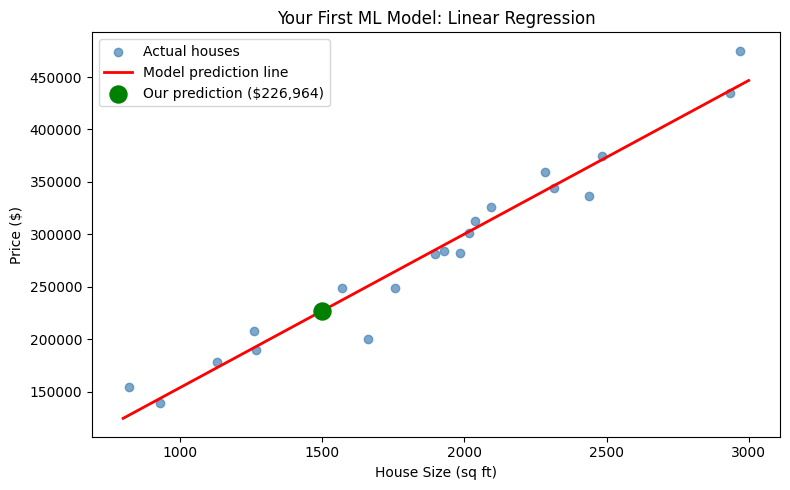


✅ You just trained and used your first machine learning model!


In [5]:
# ── Your First ML Model ───────────────────────────────────────────────────────
# Do NOT worry about memorizing this. Just run it and read the output.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- STEP 1: Define the problem ---
# We want to predict house price from house size (square feet)

# --- STEP 2: Create toy data ---
# Imagine we recorded 20 houses: size (sq ft) and price ($)
np.random.seed(42)  # makes results reproducible (same "random" numbers every run)
house_sizes = np.random.randint(800, 3000, size=20)          # random sizes 800–3000 sq ft
house_prices = house_sizes * 150 + np.random.randn(20) * 20000  # price ≈ $150/sqft + noise

print("Sample data (first 5 houses):")
for size, price in zip(house_sizes[:5], house_prices[:5]):
    print(f"  Size: {size} sq ft → Price: ${price:,.0f}")

# --- STEP 3: Prepare data (reshape for sklearn) ---
X = house_sizes.reshape(-1, 1)  # sklearn needs 2D input
y = house_prices

# --- STEP 4: Train a model ---
model = LinearRegression()   # pick the algorithm
model.fit(X, y)              # TRAIN: find the best line through the data

# --- STEP 5: Evaluate ---
r_squared = model.score(X, y)
print(f"\nModel R² score: {r_squared:.3f}")
print(f"(R²=1.0 means perfect. R²=0.0 means the model learns nothing.)")

# --- STEP 6: Make predictions ---
new_house_size = np.array([[1500]])  # predict price for 1500 sq ft house
predicted_price = model.predict(new_house_size)[0]
print(f"\nPredicted price for 1500 sq ft house: ${predicted_price:,.0f}")

# --- BONUS: Plot the model ---
sizes_range = np.linspace(800, 3000, 100).reshape(-1, 1)
predicted_line = model.predict(sizes_range)

plt.figure(figsize=(8, 5))
plt.scatter(house_sizes, house_prices, color='steelblue', alpha=0.7, label='Actual houses')
plt.plot(sizes_range, predicted_line, color='red', linewidth=2, label='Model prediction line')
plt.scatter([1500], [predicted_price], color='green', s=150, zorder=5, label=f'Our prediction (${predicted_price:,.0f})')
plt.xlabel('House Size (sq ft)')
plt.ylabel('Price ($)')
plt.title('Your First ML Model: Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

print("\n✅ You just trained and used your first machine learning model!")

**Understanding the output:**
- The blue dots are the real houses in your dataset
- The red line is what the model learned — the best linear relationship between size and price
- The green dot is a prediction for a house that was NOT in the training data
- The R² score tells you how well the model explains the variation in prices (closer to 1.0 = better fit)

This is all 6 steps of the ML workflow in one cell. Over the next 39 weeks you'll learn to do each step properly, at production quality.

---

## Section 6: The ML Landscape Map

You'll encounter hundreds of terms in this field. Here is a map so you always know where things fit:

```
MACHINE LEARNING
├── Supervised Learning
│   ├── Classification (output = category)
│   │   ├── Logistic Regression     ← you'll use this week 5
│   │   ├── Decision Tree
│   │   ├── Random Forest           ← most used in industry
│   │   ├── XGBoost / LightGBM      ← wins Kaggle competitions
│   │   └── Neural Networks         ← weeks 17-20
│   └── Regression (output = number)
│       ├── Linear Regression       ← you just saw this!
│       ├── Ridge / Lasso
│       └── Gradient Boosting
├── Unsupervised Learning
│   ├── Clustering (K-Means, DBSCAN)
│   ├── Dimensionality Reduction (PCA, UMAP)
│   └── Anomaly Detection
├── Deep Learning
│   ├── Convolutional Neural Nets (CNN) — images
│   ├── Recurrent Neural Nets (RNN) — sequences
│   └── Transformers — text, audio, images (GPT, BERT)
└── Reinforcement Learning
    └── Q-Learning, PPO, RLHF
```

**Don't memorize this.** Come back to it as a reference when you encounter a new term.

---

## Week 0 Reflection Questions

Write your answers in the cell below. These are not graded — writing forces you to think.

1. In your own words, what is the difference between AI and Machine Learning?
2. Give a real-world example of a supervised classification problem you encounter in your daily life.
3. Give a real-world example of a supervised regression problem.
4. What are the 6 steps of the ML workflow? Name them without looking.
5. What does R² = 0.95 mean for a model?

**Your answers here (double-click to edit):**

1. 

2. 

3. 

4. 

5. 

---

## Week 0 Checklist — Before You Move to Week 1

- [ ] I can explain what ML is in one sentence without using jargon
- [ ] I can name the 3 types of ML and give a real-world example of each
- [ ] I can name all 6 steps of the ML workflow
- [ ] I ran every code cell in this notebook
- [ ] I scored at least 3/4 on the ML Type exercise
- [ ] I scored at least 4/6 on the 6-step exercise
- [ ] I wrote answers to the reflection questions
- [ ] I can read a Python error message without panicking

**If you checked all boxes → go to STARTER_Week1_PythonBasics.ipynb**